<a href="https://colab.research.google.com/github/NehalShahu/NNDL_practicals/blob/main/NNDL_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

## 2. Load Sequential Time Series Data

In [2]:
# Load GlobalTemperatures.csv for this analysis
df = pd.read_csv('/content/GlobalTemperatures.csv')
display(df.head())

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Preprocess the Data

In [3]:
# Select relevant columns: 'dt' (Date) and 'LandAverageTemperature'
df_temp = df[['dt', 'LandAverageTemperature']].copy()

# Rename 'dt' to 'Date' for clarity
df_temp = df_temp.rename(columns={'dt': 'Date'})

# Convert 'Date' column to datetime objects
df_temp['Date'] = pd.to_datetime(df_temp['Date'])

# Set 'Date' as the index and sort by date
df_temp = df_temp.set_index('Date').sort_index()

# Handle missing values: Fill NaNs in 'LandAverageTemperature' using linear interpolation
df_temp['LandAverageTemperature'] = df_temp['LandAverageTemperature'].interpolate(method='linear')

# Drop any remaining NaNs (e.g., if there are NaNs at the very beginning/end that can't be interpolated)
df_temp.dropna(inplace=True)

display(df_temp.head())
display(df_temp.info())


,LandAverageTemperature
Date,
1750-01-01,3.034
1750-02-01,3.083
1750-03-01,5.626
1750-04-01,8.490
1750-05-01,11.573


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3192 entries, 1750-01-01 to 2015-12-01
Data columns (total 1 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   LandAverageTemperature  3192 non-null   float64
dtypes: float64(1)
memory usage: 49.9 KB


None

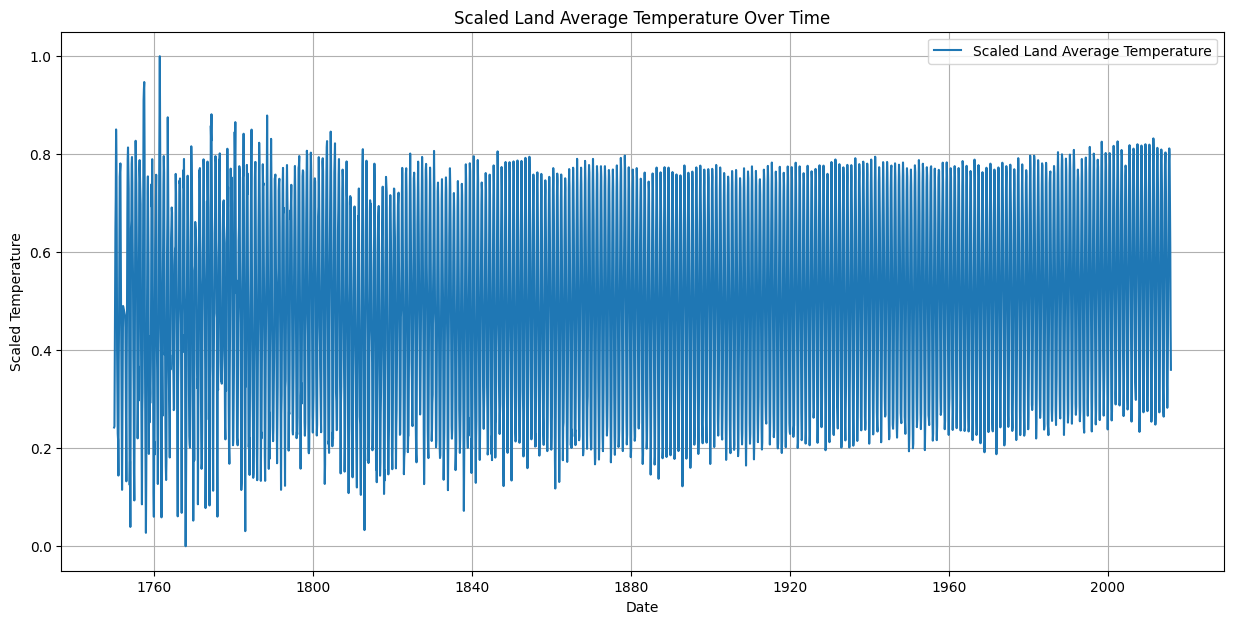

In [4]:
# Normalize the 'LandAverageTemperature' data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
df_temp['LandAverageTemperature_scaled'] = scaler.fit_transform(df_temp[['LandAverageTemperature']])

# Visualize the scaled data
plt.figure(figsize=(15, 7))
plt.plot(df_temp.index, df_temp['LandAverageTemperature_scaled'], label='Scaled Land Average Temperature')
plt.title('Scaled Land Average Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Scaled Temperature')
plt.legend()
plt.grid(True)
plt.show()

## 4. Create Input Sequences

In [5]:
def create_sequences(data, seq_length):
    xs = []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        xs.append(x)
    return np.array(xs)

# Define the sequence length (e.g., 30 months)
SEQUENCE_LENGTH = 30

# Get the scaled temperature values
data_scaled = df_temp['LandAverageTemperature_scaled'].values

# Create sequences
X = create_sequences(data_scaled, SEQUENCE_LENGTH)

# Reshape data for LSTM input: [samples, timesteps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"Shape of input sequences: {X.shape}")

# Split data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print(f"Shape of training sequences: {X_train.shape}")
print(f"Shape of testing sequences: {X_test.shape}")

Shape of input sequences: (3162, 30, 1)
Shape of training sequences: (2529, 30, 1)
Shape of testing sequences: (633, 30, 1)


## 5. Build LSTM Model

In [6]:
latent_dim = 16 # Dimension of the latent space

# Encoder
inputs = Input(shape=(SEQUENCE_LENGTH, 1))
encoder = LSTM(latent_dim, activation='relu', return_sequences=True)(inputs)
encoder = LSTM(latent_dim // 2, activation='relu', return_sequences=False)(encoder)

# Decoder
decoder = RepeatVector(SEQUENCE_LENGTH)(encoder)
decoder = LSTM(latent_dim // 2, activation='relu', return_sequences=True)(decoder)
decoder = LSTM(latent_dim, activation='relu', return_sequences=True)(decoder)
outputs = TimeDistributed(Dense(1))(decoder)

# Autoencoder Model
autoencoder = Model(inputs, outputs)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 16)         │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 8)          │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 16)         │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │            17 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,113 (16.07 KB)

 Trainable params: 4,113 (16.07 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Compile and Train

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - loss: 0.1645 - val_loss: 0.0739
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0667 - val_loss: 0.0597
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0556 - val_loss: 0.0496
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0467 - val_loss: 0.0429
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0423 - val_loss: 0.0411
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0400 - val_loss: 0.0391
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0383 - val_loss: 0.0357
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0334 - val_loss: 0.0326
Epoch 9/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 0.0295 - val_loss: 0.0322
Epoch 10/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0269 - val_loss: 0.0268
Epoch 11/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0237 - val_loss: 0.0238
Epoch 12/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0

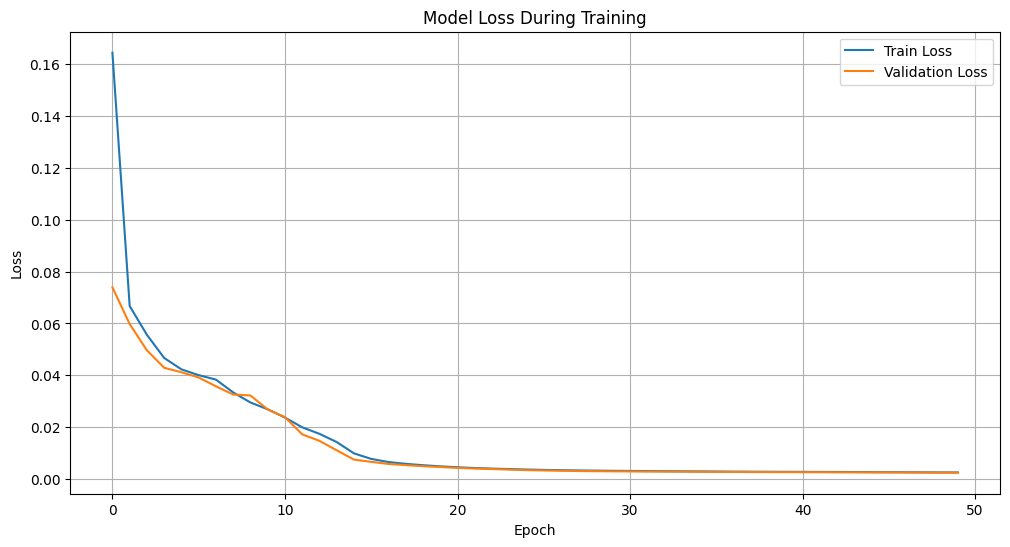

In [7]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn = tf.keras.losses.MeanSquaredError()

autoencoder.compile(optimizer=optimizer, loss=loss_fn)

# Train the autoencoder
history = autoencoder.fit(
    X_train, X_train, # Input and target are the same for autoencoders
    epochs=50,       # Number of training epochs
    batch_size=32,   # Batch size for training
    validation_split=0.1, # Use 10% of training data for validation
    shuffle=False    # Important for time series data
)

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

## 7. Reconstruct the Input Sequence & 8. Calculate Reconstruction Error

In [8]:
# Predict reconstructions for training and test data
X_train_pred = autoencoder.predict(X_train)
X_test_pred = autoencoder.predict(X_test)

# Calculate reconstruction errors (Mean Absolute Error) for both datasets
train_mae_loss = np.mean(np.abs(X_train_pred - X_train), axis=1)
test_mae_loss = np.mean(np.abs(X_test_pred - X_test), axis=1)

print(f"Average MAE loss on training data: {np.mean(train_mae_loss):.4f}")
print(f"Average MAE loss on test data: {np.mean(test_mae_loss):.4f}")

80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Average MAE loss on training data: 0.0348
Average MAE loss on test data: 0.0355


## 9. Visualize Original and Reconstruct Sequence

In [15]:
# Predict reconstructions for training and test data
X_train_pred = autoencoder.predict(X_train)
X_test_pred = autoencoder.predict(X_test)

# Calculate reconstruction errors (Mean Squared Error) for both datasets
train_mse_loss = np.mean(np.square(X_train_pred - X_train), axis=1)
test_mse_loss = np.mean(np.square(X_test_pred - X_test), axis=1)

print(f"Average MSE loss on training data: {np.mean(train_mse_loss):.4f}")
print(f"Average MSE loss on test data: {np.mean(test_mse_loss):.4f}")

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Average MSE loss on training data: 0.0026
Average MSE loss on test data: 0.0027


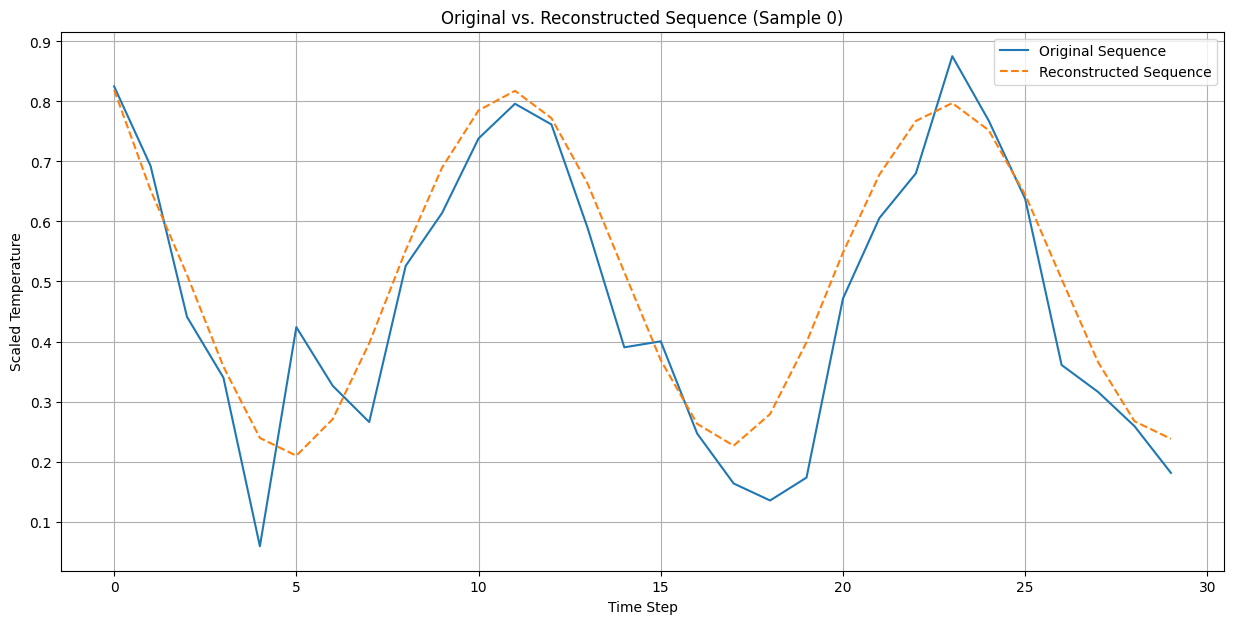

In [9]:
# Choose a sample from the test set to visualize
sample_index = 0

# Get original and reconstructed sequence for the chosen sample
original_sequence = X_test[sample_index].reshape(-1)
reconstructed_sequence = X_test_pred[sample_index].reshape(-1)

# Plot the original and reconstructed sequences
plt.figure(figsize=(15, 7))
plt.plot(original_sequence, label='Original Sequence')
plt.plot(reconstructed_sequence, label='Reconstructed Sequence', linestyle='--')
plt.title(f'Original vs. Reconstructed Sequence (Sample {sample_index})')
plt.xlabel('Time Step')
plt.ylabel('Scaled Temperature')
plt.legend()
plt.grid(True)
plt.show()

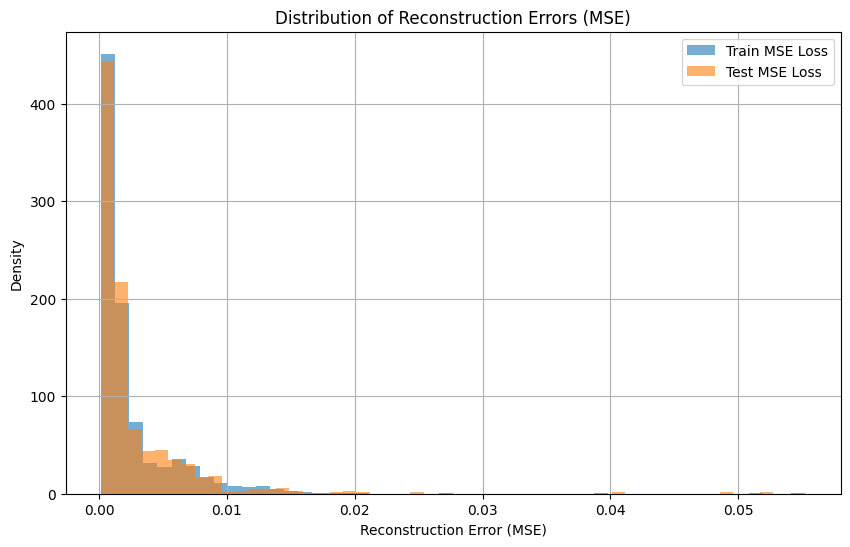

In [17]:
# Also visualize the distribution of reconstruction errors for anomaly detection thresholding
plt.figure(figsize=(10, 6))
plt.hist(train_mse_loss, bins=50, density=True, alpha=0.6, label='Train MSE Loss')
plt.hist(test_mse_loss, bins=50, density=True, alpha=0.6, label='Test MSE Loss')
plt.title('Distribution of Reconstruction Errors (MSE)')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

## 10. Evaluate the Model (Anomaly Detection)

Anomaly threshold (95th percentile of training MSE loss): 0.0093
Number of anomalous points detected in the test set: 27


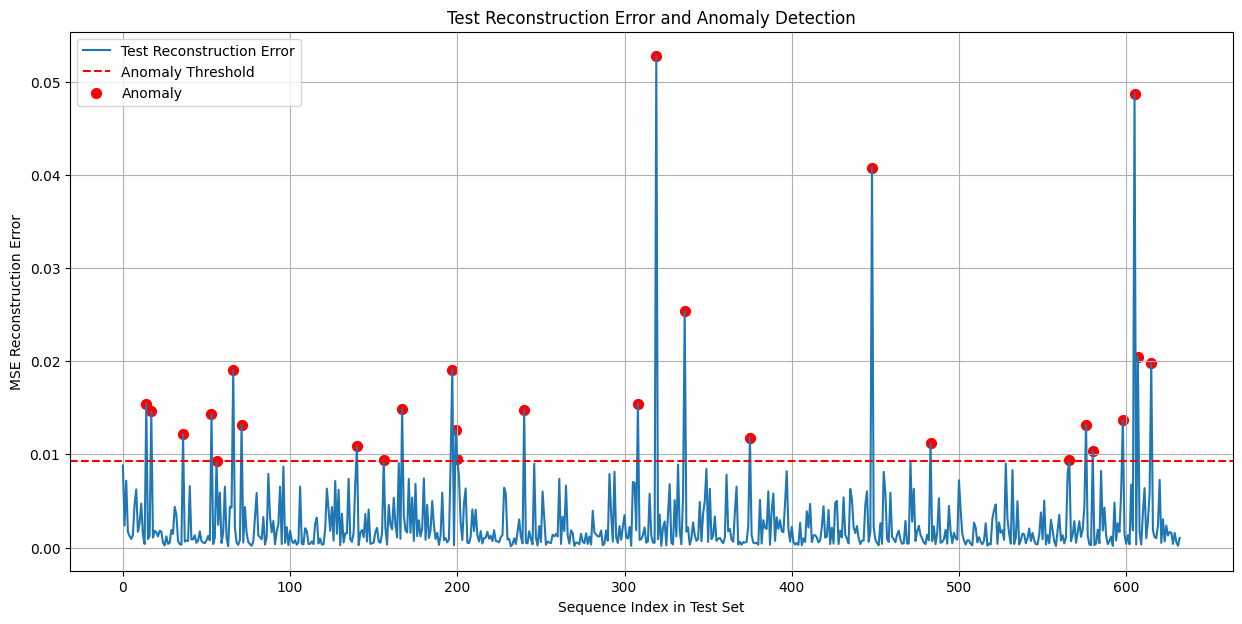

In [16]:
# Determine a threshold for anomaly detection
# A common approach is to use a multiple of the standard deviation or a percentile of the training MSE loss.
# Let's use the 95th percentile of the training MSE loss as the threshold.
threshold = np.percentile(train_mse_loss, 95)
print(f"Anomaly threshold (95th percentile of training MSE loss): {threshold:.4f}")

# Identify anomalies in the test set
anomalies = test_mse_loss > threshold

print(f"Number of anomalous points detected in the test set: {np.sum(anomalies)}")

# To visualize anomalies, let's map the anomaly flags back to the original time series data.
# Note: The test set `X_test` corresponds to a portion of `data_scaled`.
# We need to find the original indices for these test sequences to plot them correctly.

# Create a DataFrame for full data with reconstruction error for visualization
full_data_error = pd.DataFrame(index=df_temp.index[SEQUENCE_LENGTH:])

# Add the scaled temperature for plotting
full_data_error['LandAverageTemperature_scaled'] = data_scaled[SEQUENCE_LENGTH:]

# Placeholder for errors (we'll fill this with actual train/test errors)
full_data_error['Reconstruction_Error'] = np.nan
full_data_error['Is_Anomaly'] = False

# Get the original indices for X_train and X_test to place errors back correctly
# This assumes create_sequences was applied to `data_scaled` directly.
# The `train_test_split` shuffled the data, so re-indexing is complex for exact position mapping.
# For simpler visualization, we will just plot the test set anomalies on a subset of the original data.

# Let's create an index for the sequences for easier mapping.
# The indices of `X` correspond to the starting point of each sequence in `data_scaled`.
original_indices = np.arange(SEQUENCE_LENGTH, len(data_scaled))

# Since X_test is a shuffled subset of X, mapping back to original time index for direct plotting is non-trivial.
# We'll plot the anomalies detected in the test set against their reconstruction error values.

# Plot reconstruction errors for the test set and the anomaly threshold
plt.figure(figsize=(15, 7))
plt.plot(test_mse_loss, label='Test Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Anomaly Threshold')
plt.scatter(np.where(anomalies)[0], test_mse_loss[anomalies], color='red', s=50, label='Anomaly')
plt.title('Test Reconstruction Error and Anomaly Detection')
plt.xlabel('Sequence Index in Test Set')
plt.ylabel('MSE Reconstruction Error')
plt.legend()
plt.grid(True)
plt.show()

# If you want to see the anomalous sequences in the context of the original time series:
# This requires careful re-indexing because train_test_split shuffles.
# For now, let's just show the error distribution.


## Check Output on Given Data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Original Input Sequence (Sample 277):
[0.48703853 0.37709113 0.33913085 0.25084119 0.24510687 0.35282688
 0.5245249  0.60807545 0.75091228 0.76238093 0.72740628 0.62688972
 0.47670727 0.38566893 0.24250036 0.18828492 0.17122411 0.33022132
 0.4968011  0.65797829 0.7156059  0.78489171 0.71982371 0.62831145
 0.499455   0.41296621 0.32965262 0.26884982 0.30780532 0.38960239]

Reconstructed Output Sequence:
[0.48743945 0.3973501  0.25471774 0.22013475 0.27161938 0.3695673
 0.496196   0.62538826 0.72635907 0.7722934  0.74827045 0.65754837
 0.5233349  0.3837446  0.27857485 0.23914157 0.27643457 0.3783553
 0.51554173 0.6471727  0.74237645 0.786578   0.762411   0.6707001
 0.53302234 0.38879144 0.27529782 0.2285406  0.26340055 0.36941025]


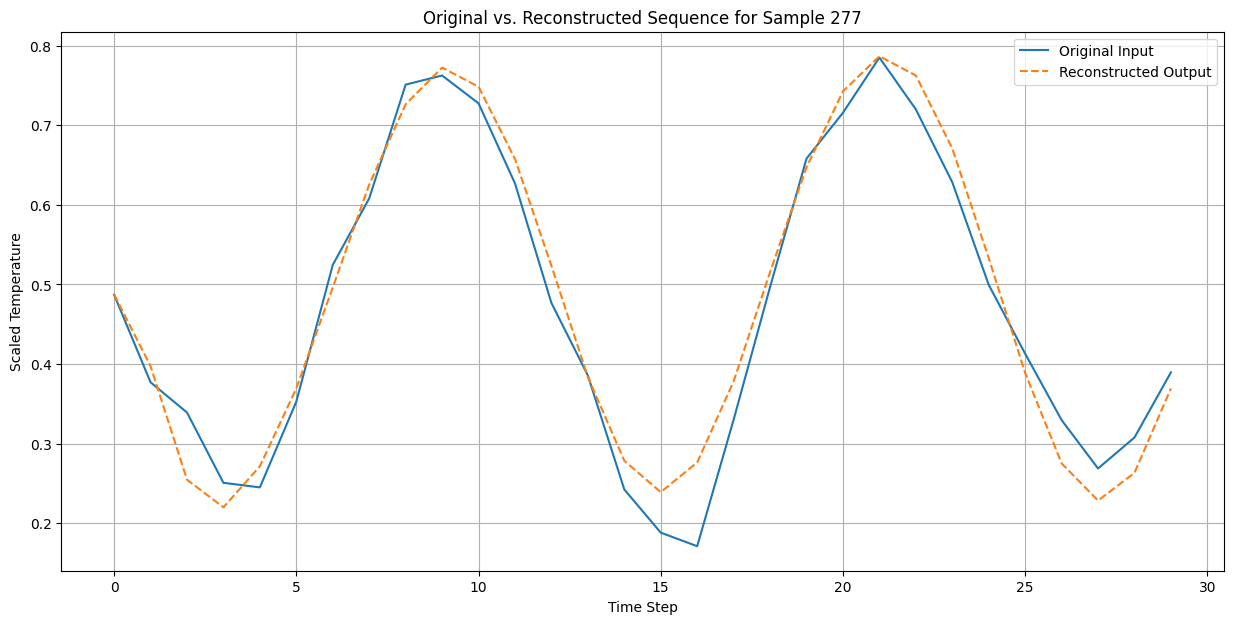

In [18]:
import random

# Select a random index from the test set to demonstrate
random_sample_index = random.randint(0, len(X_test) - 1)

# Get an original sequence from the test set
original_input_sequence = X_test[random_sample_index]

# Reshape the input for prediction (add batch dimension if needed, but predict handles it for single sample)
input_for_prediction = np.expand_dims(original_input_sequence, axis=0)

# Use the trained autoencoder to predict the reconstruction
reconstructed_output_sequence = autoencoder.predict(input_for_prediction)

# Reshape the output to remove the batch dimension and feature dimension for plotting/comparison
original_sequence_flat = original_input_sequence.reshape(-1)
reconstructed_sequence_flat = reconstructed_output_sequence.reshape(-1)

print(f"Original Input Sequence (Sample {random_sample_index}):")
print(original_sequence_flat)
print("\nReconstructed Output Sequence:")
print(reconstructed_sequence_flat)

# Optionally, visualize this specific sample's original vs. reconstructed sequence
plt.figure(figsize=(15, 7))
plt.plot(original_sequence_flat, label='Original Input')
plt.plot(reconstructed_sequence_flat, label='Reconstructed Output', linestyle='--')
plt.title(f'Original vs. Reconstructed Sequence for Sample {random_sample_index}')
plt.xlabel('Time Step')
plt.ylabel('Scaled Temperature')
plt.legend()
plt.grid(True)
plt.show()